In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spark = (
    SparkSession.builder
    .master("spark://spark-master:7077")
    .appName("04_export")

    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
    .config("spark.hadoop.fs.s3a.access.key", "admin")
    .config("spark.hadoop.fs.s3a.secret.key", "admin123")

    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")

    .config(
        "spark.hadoop.fs.s3a.impl",
        "org.apache.hadoop.fs.s3a.S3AFileSystem"
    )

    .config(
        "spark.hadoop.mapreduce.fileoutputcommitter.algorithm.version",
        "2"
    )

    .config(
        "spark.sql.sources.commitProtocolClass",
        "org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol"
    )

    .config(
        "spark.sql.parquet.output.committer.class",
        "org.apache.parquet.hadoop.ParquetOutputCommitter"
    )

    .getOrCreate()
)
spark

In [3]:
gold = spark.read.parquet(
    "s3a://gold/customer_rfm"
)

print("Rows:", gold.count())

gold.show(10, False)

Rows: 5878
+----------+-------+---------+---------+-------+-------+-------+---------+-------------+
|CustomerID|Recency|Frequency|Monetary |F_Score|M_Score|R_Score|RFM_Score|Segment      |
+----------+-------+---------+---------+-------+-------+-------+---------+-------------+
|18102     |0      |145      |608821.65|5      |5      |5      |555      |Champions    |
|16446     |0      |2        |168472.5 |2      |5      |5      |525      |New Customers|
|15311     |0      |208      |116771.16|5      |5      |5      |555      |Champions    |
|17389     |0      |61       |57224.68 |5      |5      |5      |555      |Champions    |
|12748     |0      |336      |56599.39 |5      |5      |5      |555      |Champions    |
|13777     |0      |61       |56478.42 |5      |5      |5      |555      |Champions    |
|16705     |0      |42       |43515.05 |5      |5      |5      |555      |Champions    |
|17428     |0      |45       |31819.76 |5      |5      |5      |555      |Champions    |
|14051    

In [4]:
print("Customers:", gold.count())

gold.printSchema()

Customers: 5878
root
 |-- CustomerID: long (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Frequency: long (nullable = true)
 |-- Monetary: double (nullable = true)
 |-- F_Score: integer (nullable = true)
 |-- M_Score: integer (nullable = true)
 |-- R_Score: integer (nullable = true)
 |-- RFM_Score: string (nullable = true)
 |-- Segment: string (nullable = true)



In [5]:
segment = (
    gold.groupBy("Segment")
        .count()
        .orderBy(col("count").desc())
)

segment.show()

+---------------+-----+
|        Segment|count|
+---------------+-----+
|         Others| 3647|
|      Champions|  764|
|Loyal Customers|  713|
|        At Risk|  352|
|   Big Spenders|  249|
|  New Customers|  153|
+---------------+-----+



In [6]:
segment_pd = segment.toPandas()

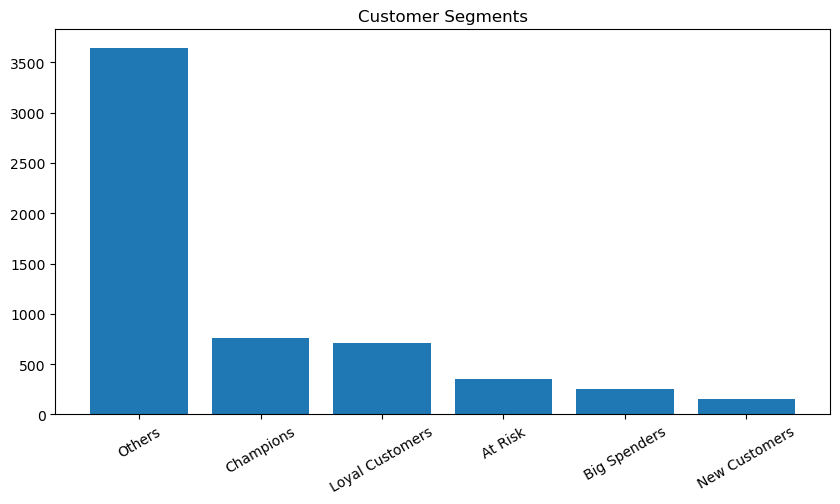

In [7]:
plt.figure(figsize=(10,5))

plt.bar(segment_pd["Segment"],
        segment_pd["count"])

plt.xticks(rotation=30)

plt.title("Customer Segments")

plt.show()

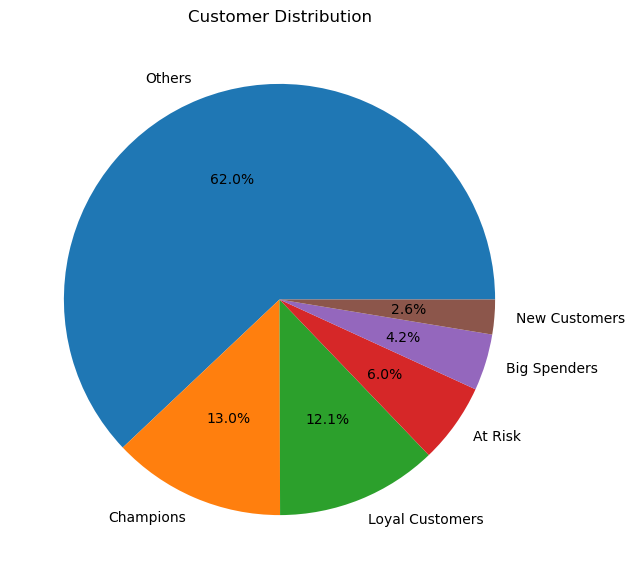

In [8]:
plt.figure(figsize=(7,7))

plt.pie(
    segment_pd["count"],
    labels=segment_pd["Segment"],
    autopct="%1.1f%%"
)

plt.title("Customer Distribution")

plt.show()

In [9]:
top10 = (
    gold.orderBy(
        col("Monetary").desc()
    )
)

top10.show(10)

+----------+-------+---------+---------+-------+-------+-------+---------+---------------+
|CustomerID|Recency|Frequency| Monetary|F_Score|M_Score|R_Score|RFM_Score|        Segment|
+----------+-------+---------+---------+-------+-------+-------+---------+---------------+
|     18102|      0|      145|608821.65|      5|      5|      5|      555|      Champions|
|     14646|      1|      151|528602.52|      5|      5|      5|      555|      Champions|
|     14156|      9|      156|313946.37|      5|      5|      5|      555|      Champions|
|     14911|      1|      398|295972.63|      5|      5|      5|      555|      Champions|
|     17450|      8|       51|246973.09|      5|      5|      5|      555|      Champions|
|     13694|      3|      143|196482.81|      5|      5|      5|      555|      Champions|
|     17511|      2|       60|175603.55|      5|      5|      5|      555|      Champions|
|     16446|      0|        2| 168472.5|      2|      5|      5|      525|  New Customers|

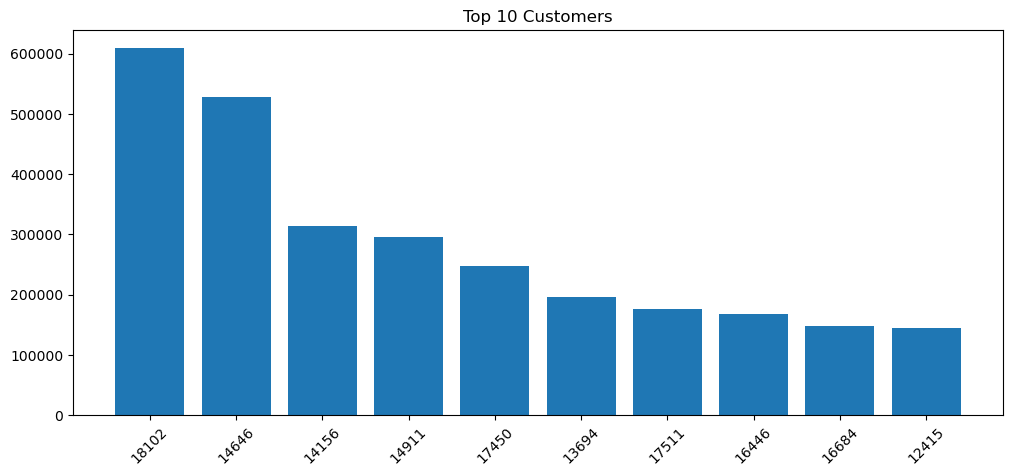

In [10]:
top10_pd = top10.limit(10).toPandas()

plt.figure(figsize=(12,5))

plt.bar(
    top10_pd["CustomerID"].astype(str),
    top10_pd["Monetary"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Customers")

plt.show()

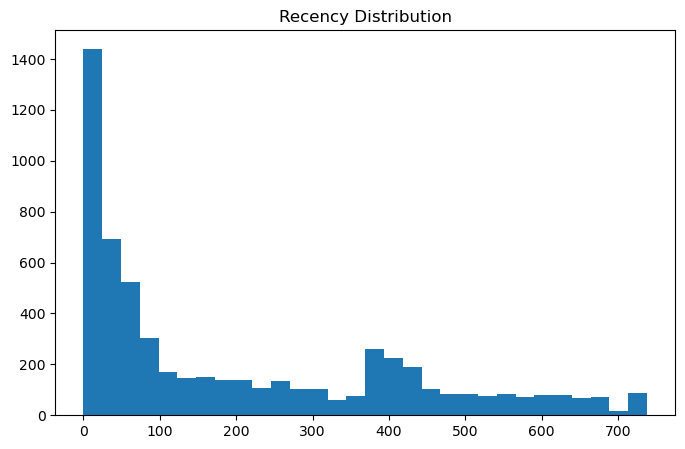

In [11]:
recency = gold.select("Recency").toPandas()

plt.figure(figsize=(8,5))

plt.hist(recency["Recency"], bins=30)

plt.title("Recency Distribution")

plt.show()

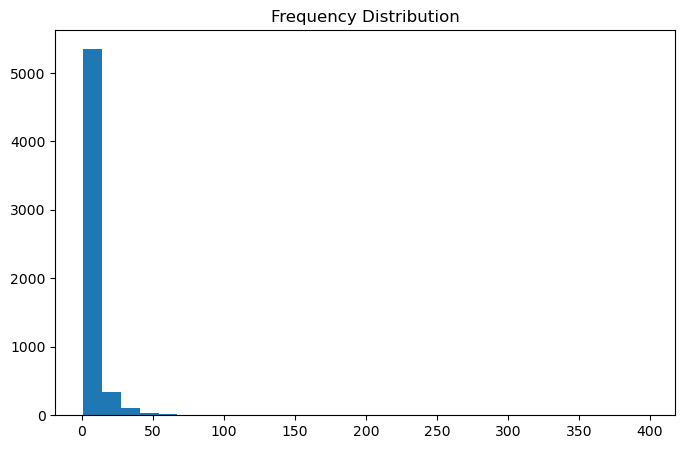

In [12]:
frequency = gold.select("Frequency").toPandas()

plt.figure(figsize=(8,5))

plt.hist(frequency["Frequency"], bins=30)

plt.title("Frequency Distribution")

plt.show()

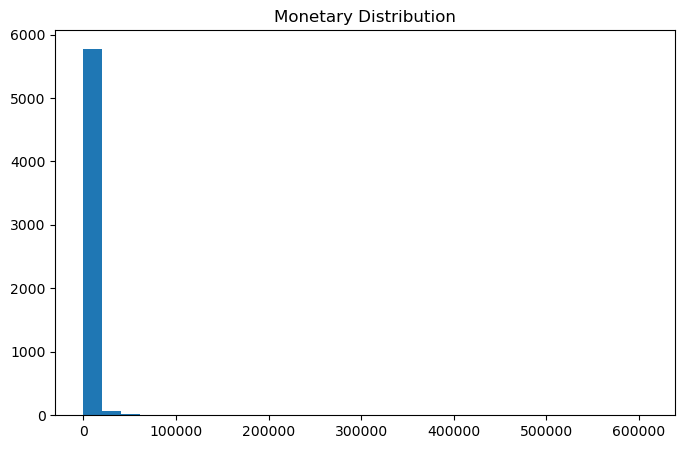

In [13]:
money = gold.select("Monetary").toPandas()

plt.figure(figsize=(8,5))

plt.hist(money["Monetary"], bins=30)

plt.title("Monetary Distribution")

plt.show()

In [15]:
import os

os.makedirs(
    "/home/jovyan/exports",
    exist_ok=True
)

gold.toPandas().to_csv(
    "/home/jovyan/exports/customer_rfm.csv",
    index=False
)

print("Export completed.")

Export completed.


In [16]:
import os

print(
    os.listdir("/home/jovyan/exports")
)

['avg_segment.csv', 'customer_rfm.csv', 'frequency_summary.csv', 'recency_summary.csv', 'segment_summary.csv', 'top_customer.csv']


In [17]:
spark.stop()